In [1]:
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import  os
import  json
import  pandas as pd
import  numpy as np
import  joblib
import  matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_val_score

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=4809c6b9febb46bbb7d60bf49cec228d97bb6b72318de2b985822b5604759db1
  Stored in directory: /tmp/pip-ephem-wheel-cache-uie2fhih/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
PLOT_FOLDER     = "TabPFN_OUTPUTS"
SLURM_RUN_FULL  = False
TEST_ROWS       = 100
SEED            = 50015

In [3]:
try:
    import tabpfn
    from tabpfn import TabPFNRegressor
    from tabpfn.constants import ModelVersion

    if SLURM_RUN_FULL:
        os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

    print(f"TabPFN version: {tabpfn.__version__}")
    print("Selected model version:", ModelVersion.V2)

except ImportError as exc:
    raise ImportError("tabpfn is not installed in this Python environment.") from exc

TabPFN version: 6.4.1
Selected model version: ModelVersion.V2


In [4]:
df = pd.read_csv("../interfacial_results_dataset_A1.csv")
print(f"Number of rows: {len(df)}")

if not SLURM_RUN_FULL:
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")
else:
    print("Full mode: using all rows")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Number of rows: 19171
Test mode: using first 100 rows only
Total samples: 100

P_bubble statistics:
count    100.000000
mean      38.602617
std        2.619909
min       35.970519
25%       36.267849
50%       37.730702
75%       40.496295
max       43.861234
Name: P_bubble, dtype: float64


In [5]:
target     = "P_bubble"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_oxygen', 'z_carbon monoxide']

Training samples:   70
Testing samples:    15
Validation samples: 15


Feature correlations with P_bubble:
temperature          0.952377
pressure             0.333296
z_carbon dioxide          NaN
z_hydrogen                NaN
z_oxygen                  NaN
z_carbon monoxide         NaN
Name: P_bubble, dtype: float64


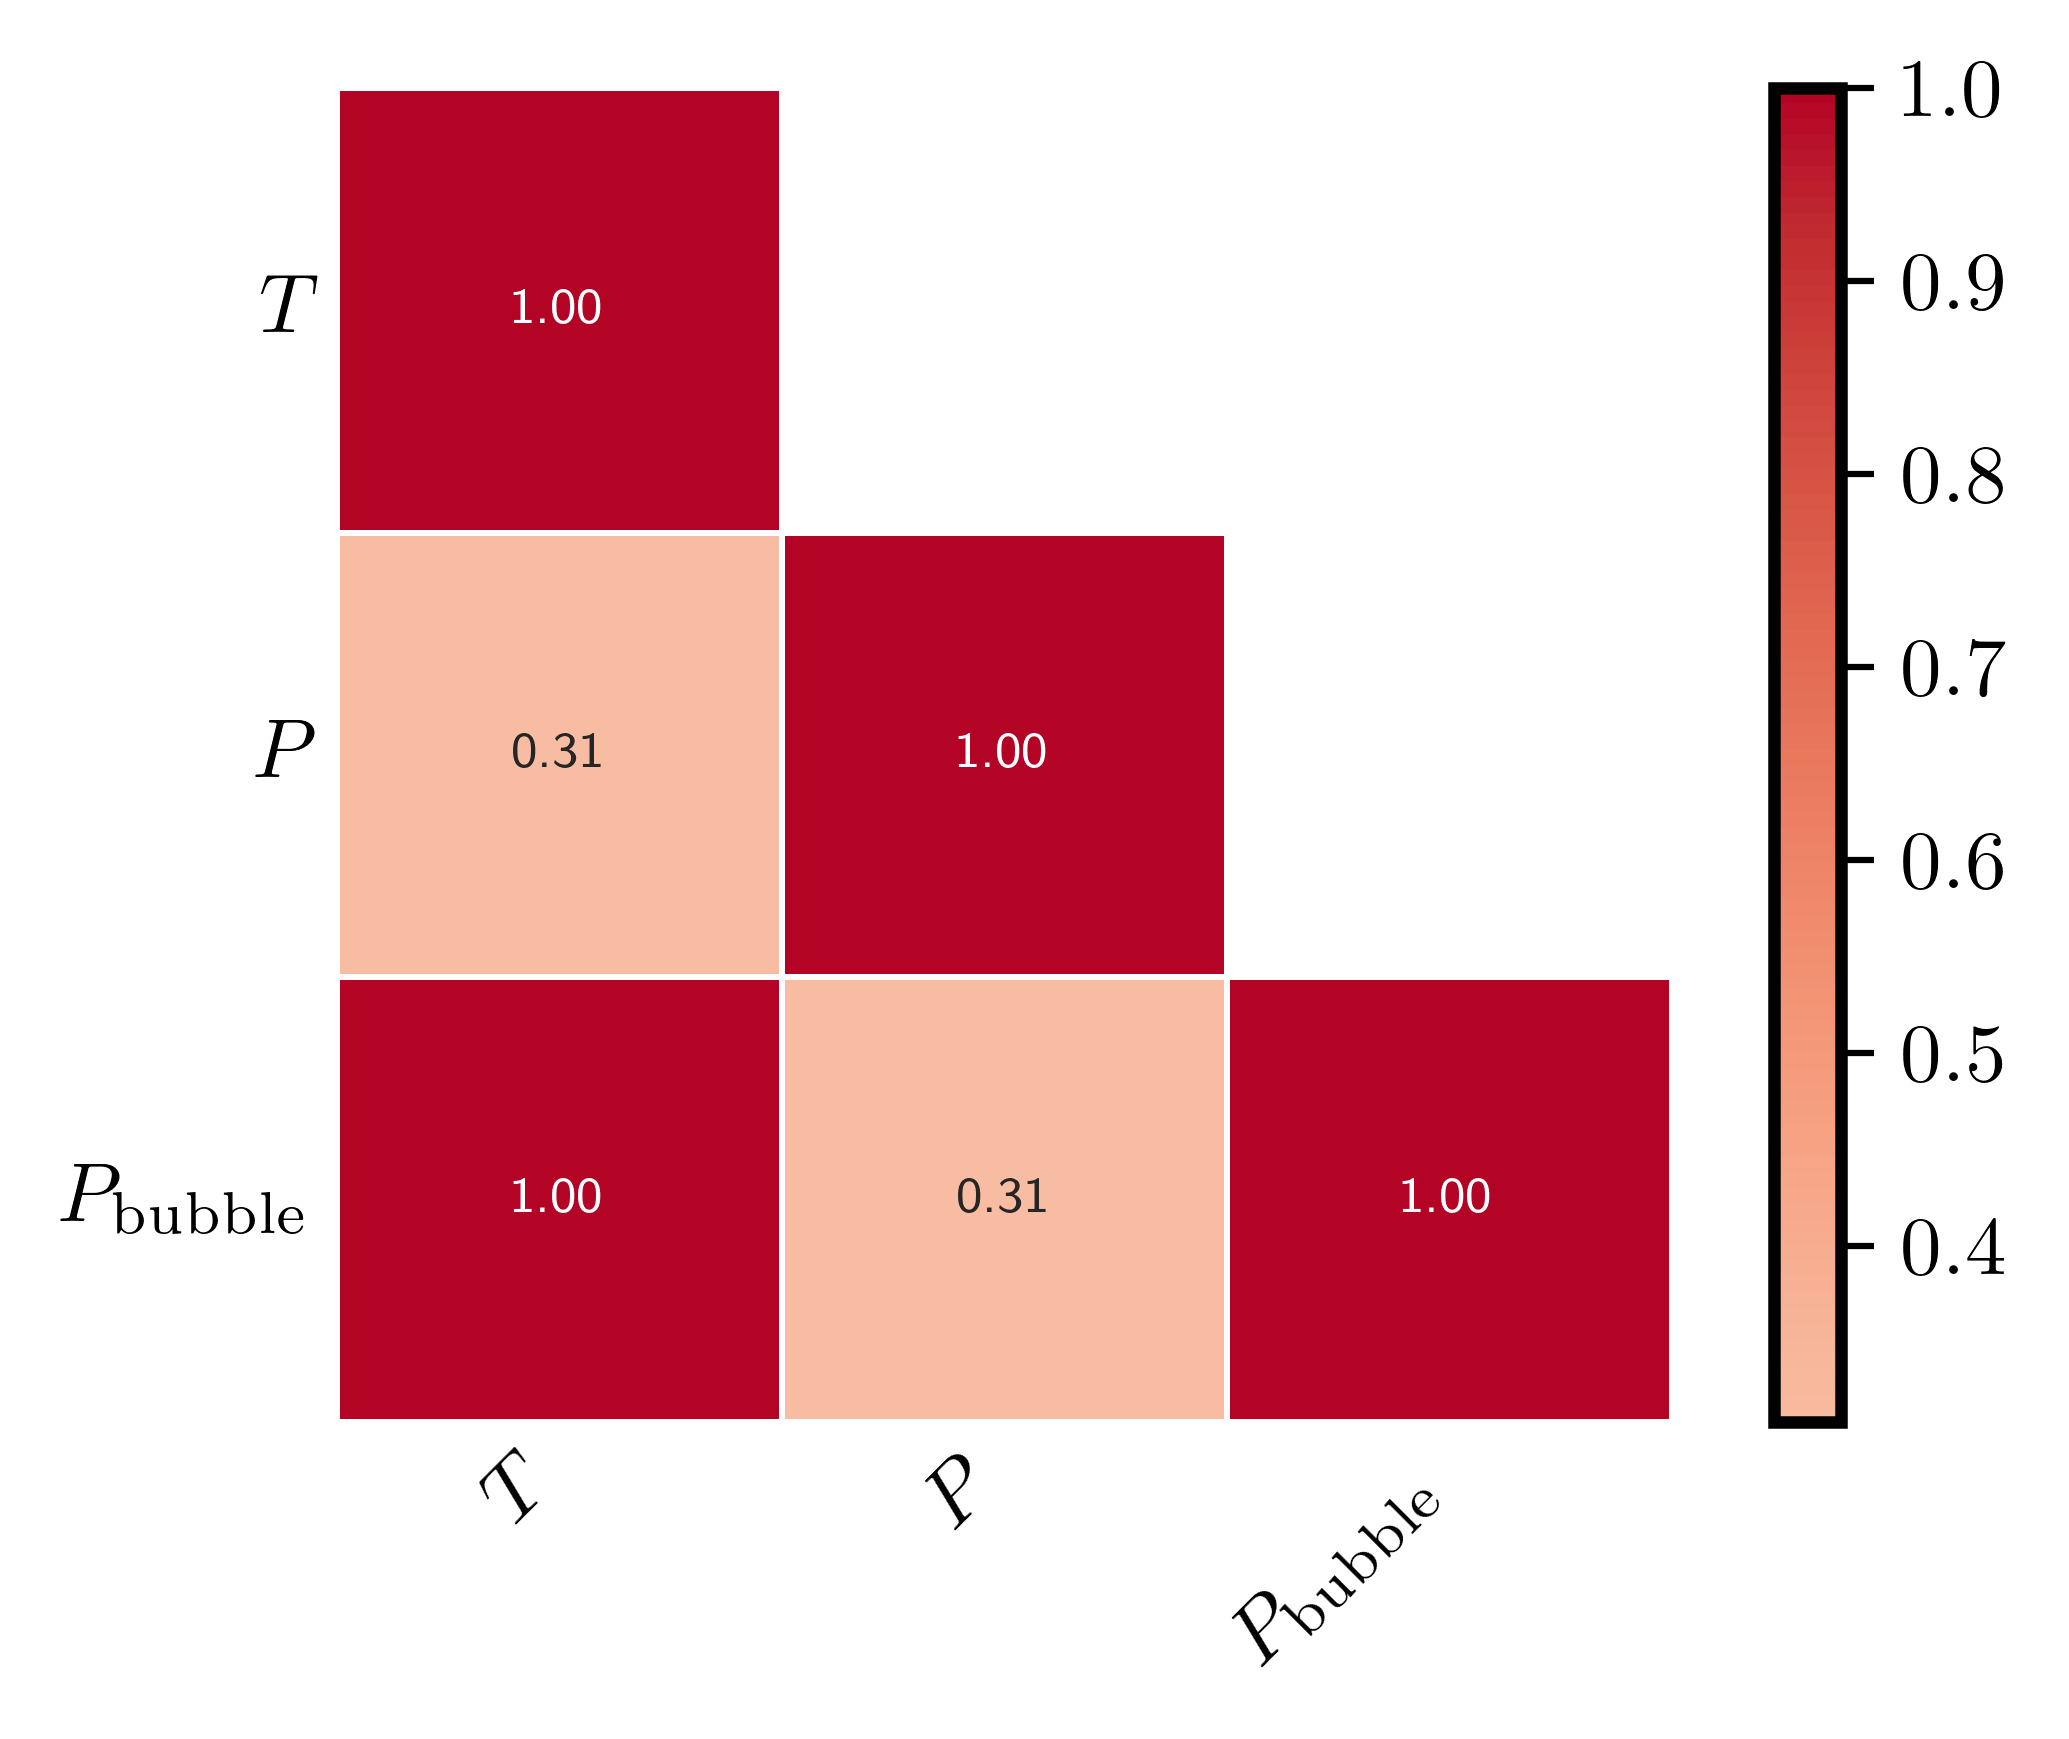

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="TabPFN_P_bubble_correlation", folder=PLOT_FOLDER)

In [7]:
# Train TabPFN model
tabpfn_model = TabPFNRegressor(random_state=SEED, ignore_pretraining_limits=True, fit_mode="fit_preprocessors")
tabpfn_model.fit(X_train, y_train)

# Predictions
y_train_pred = tabpfn_model.predict(X_train)
y_test_pred  = tabpfn_model.predict(X_test)
y_val_pred   = tabpfn_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

Model Performance for P_bubble

Training Set:
  R²:   0.999999
  RMSE: 0.002306 bar
  MAE:  0.001739 bar

Test Set:
  R²:   0.999989
  RMSE: 0.010317 bar
  MAE:  0.005262 bar

Validation Set:
  R²:   0.999996
  RMSE: 0.004759 bar
  MAE:  0.002725 bar


In [8]:
# Save predictions for post-hoc outlier analysis (no retraining needed)
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(PLOT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_model.joblib")
joblib.dump(tabpfn_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 100 rows
Model saved to: TabPFN_OUTPUTS/TabPFN_P_bubble_model.joblib


In [9]:
# 5-fold cross-validation
cv_r2_scores   = cross_val_score(tabpfn_model, X, y, cv=5, scoring='r2')
cv_rmse_scores = -cross_val_score(tabpfn_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")

Cross-Validation R² Scores:   [-8.00200306  0.39698768  0.94720624  0.8440699  -0.22524095]
Mean CV R²:   -1.207796 (+/- 6.844337)

Cross-Validation RMSE Scores: [0.08950031 0.16484528 0.09560162 0.25545576 1.005854  ]
Mean CV RMSE: 0.322251 (+/- 0.694028)


In [10]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

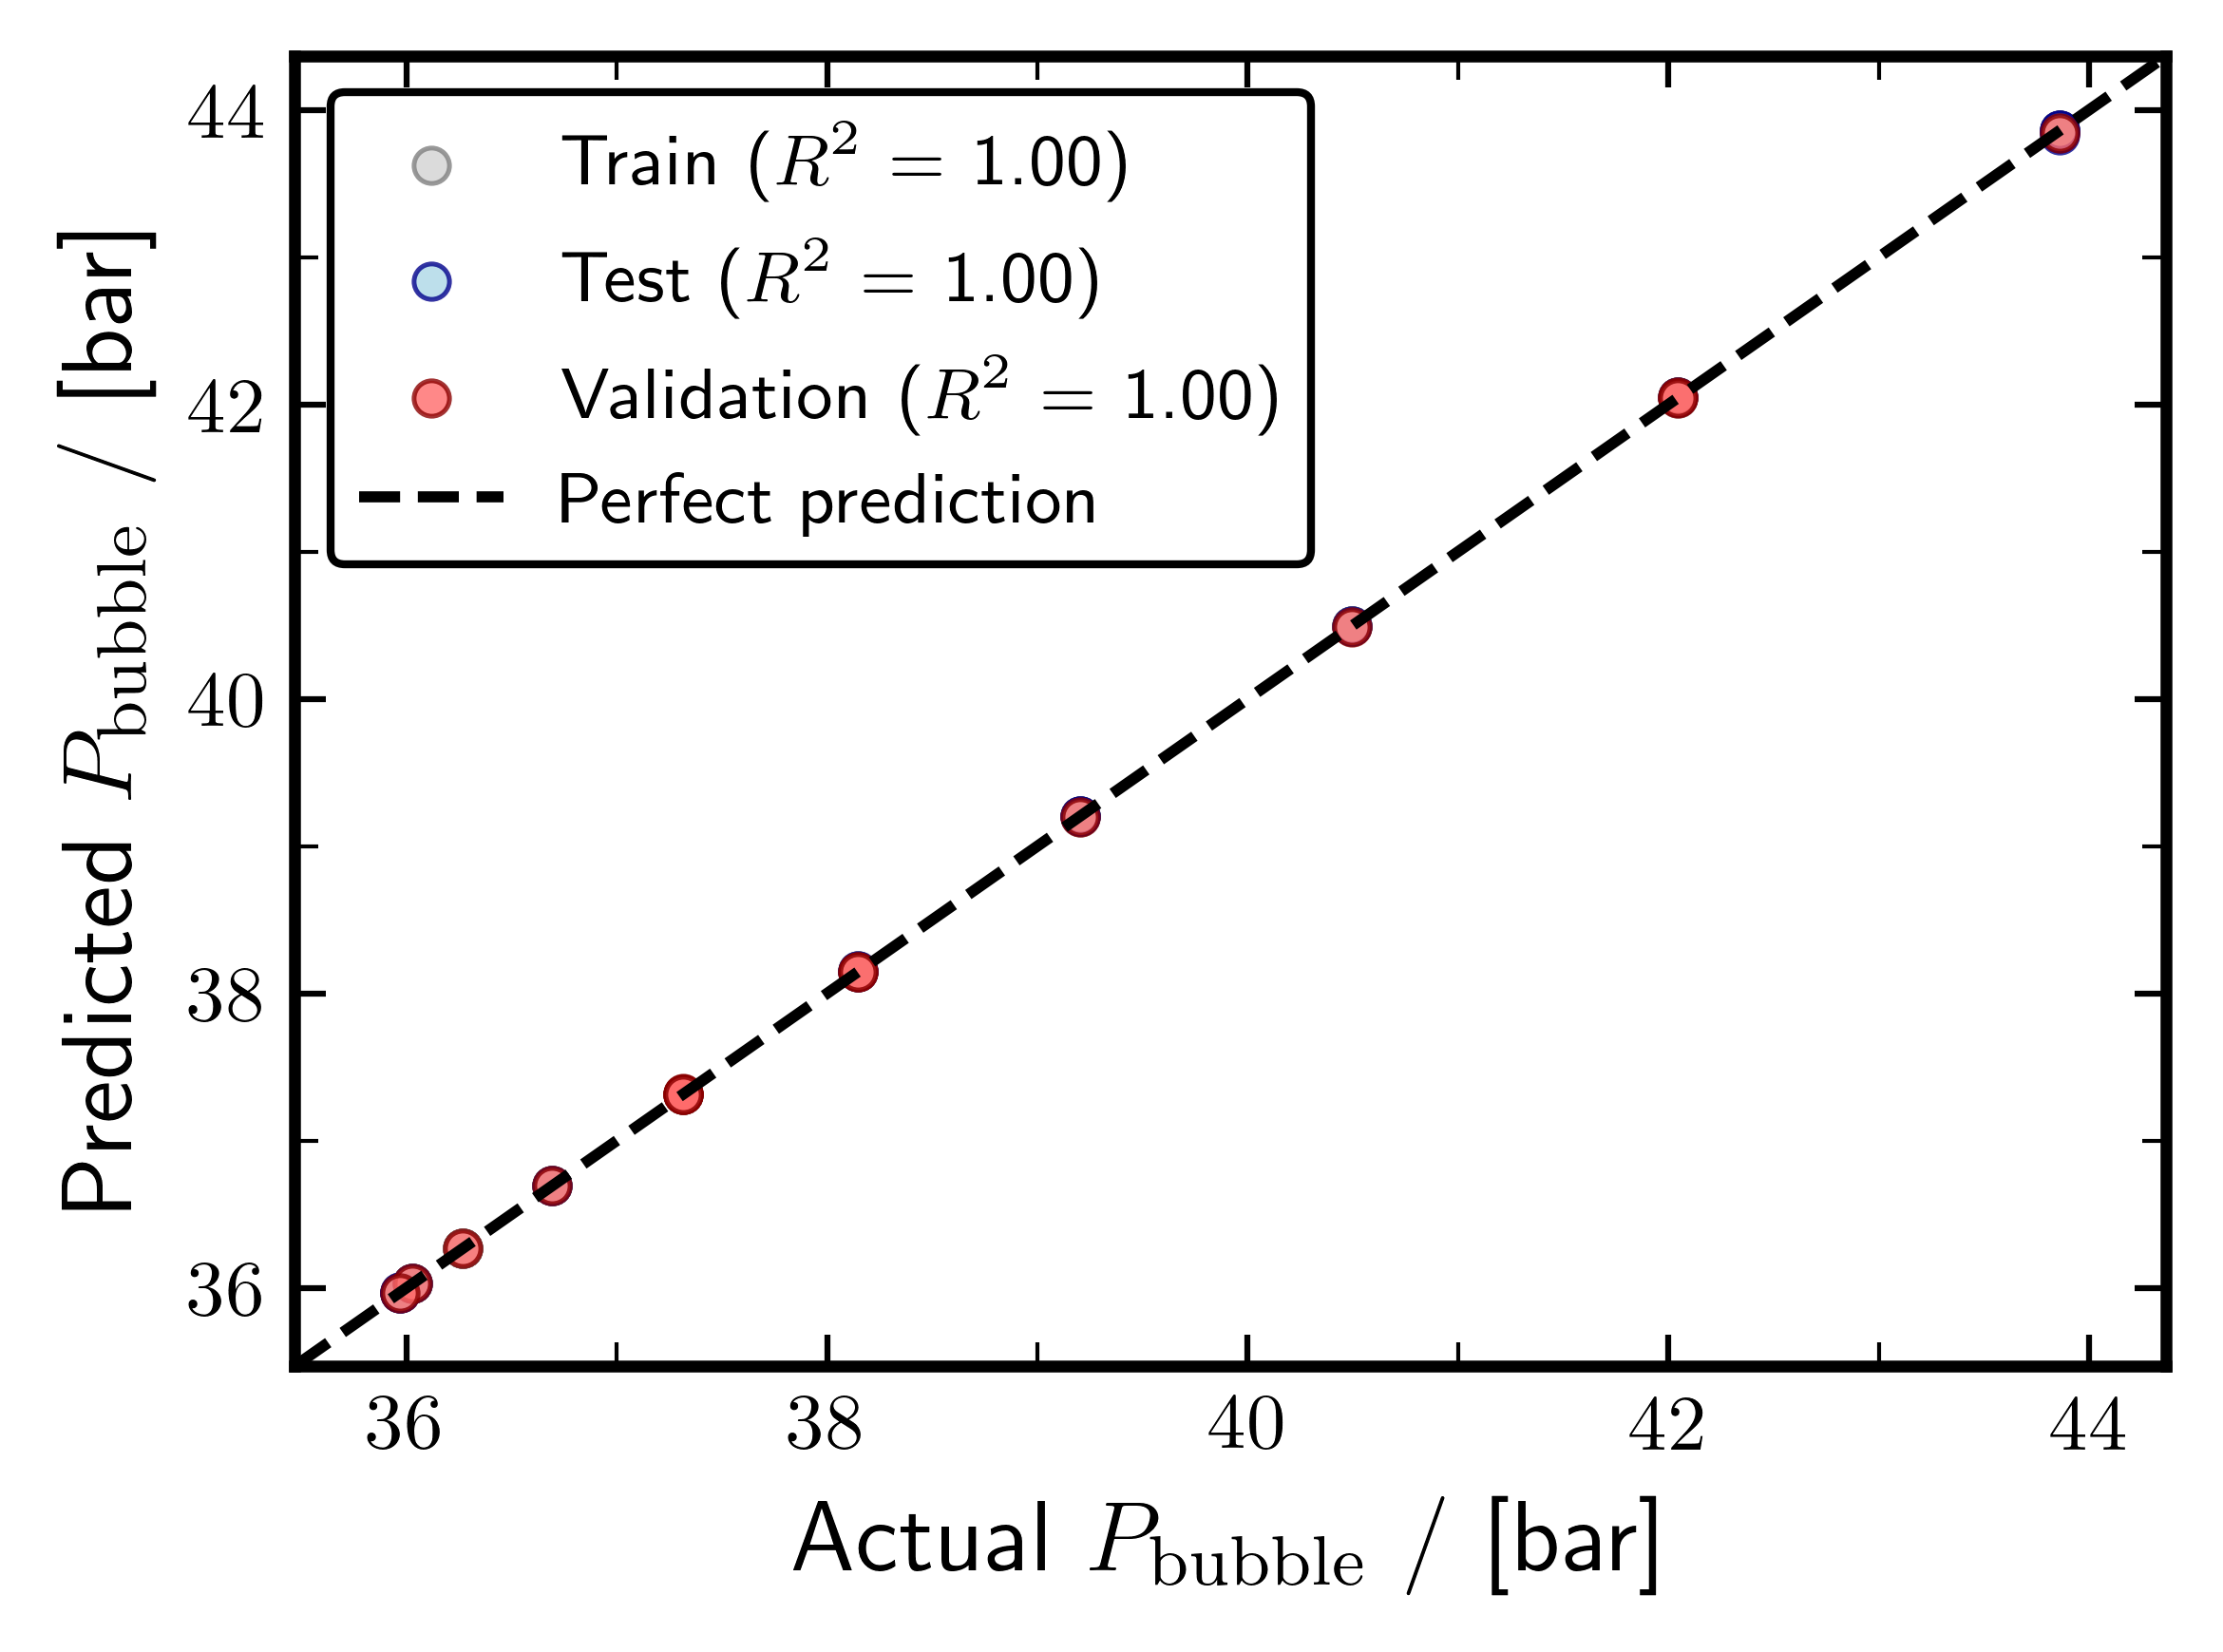

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]'>)

In [11]:
# Parity plot
post.plot_parity(model_name="TabPFN", save_path="TabPFN_P_bubble_parity_plot", folder=PLOT_FOLDER,
                #  cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                 )

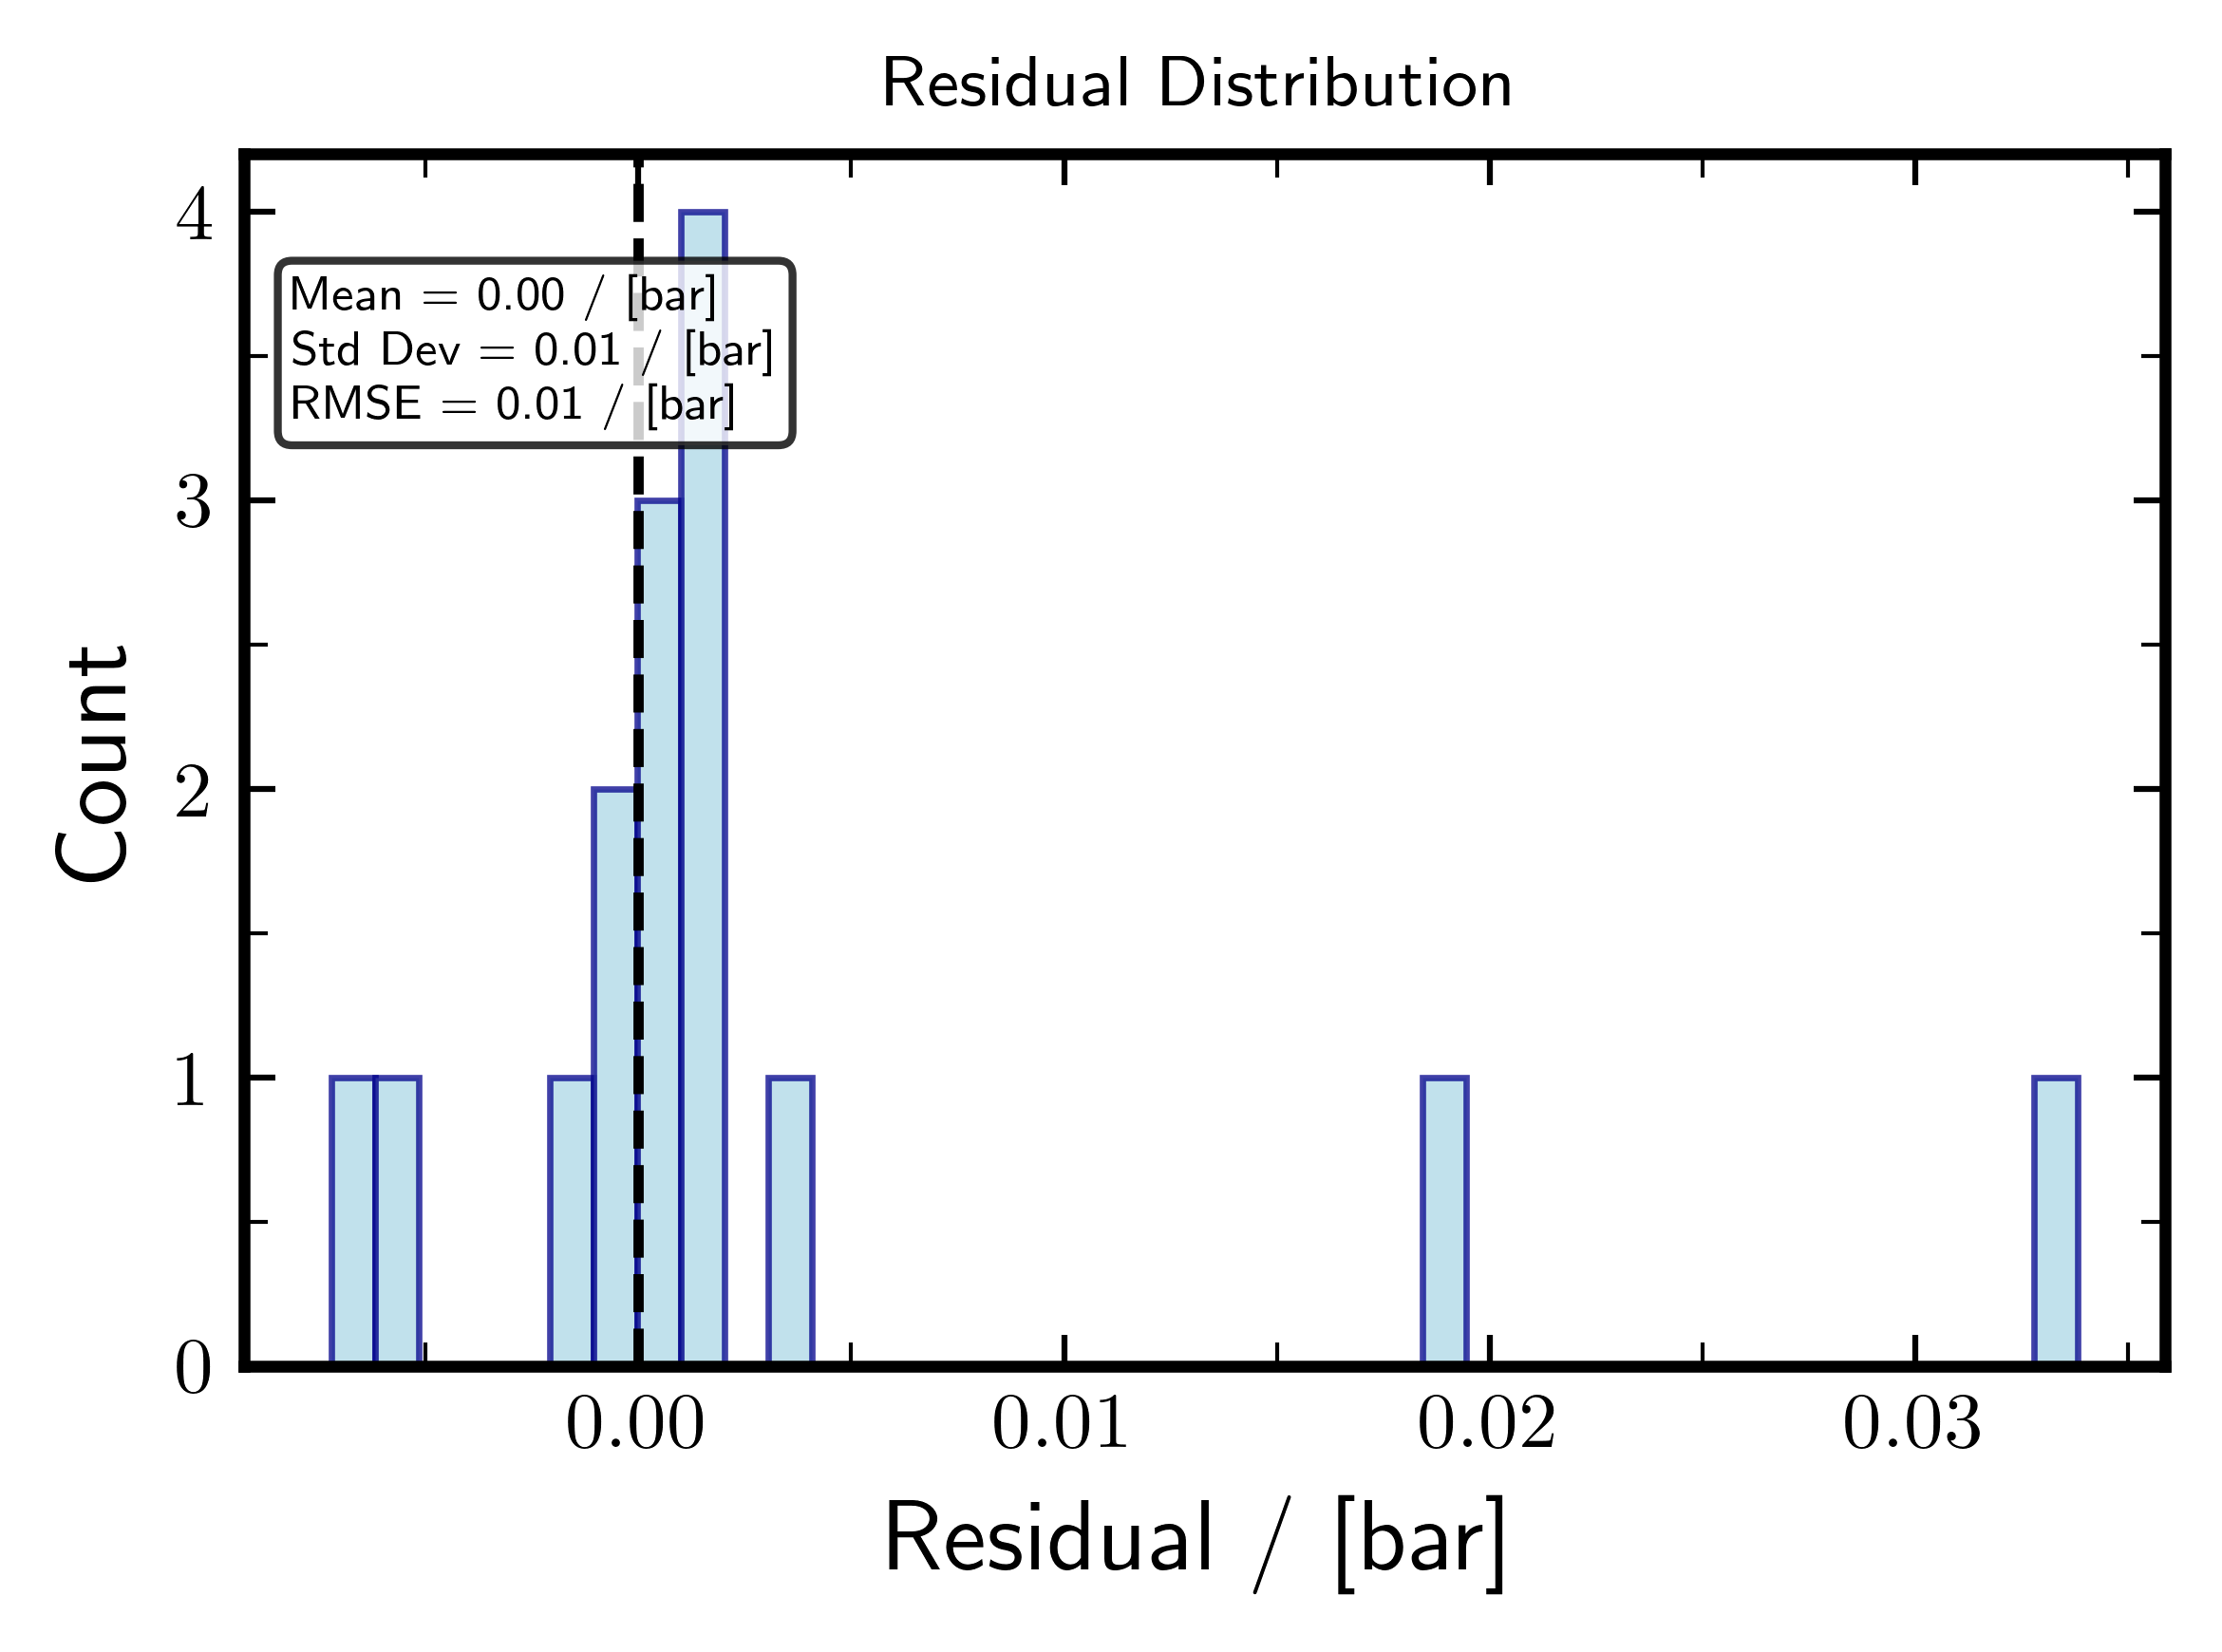

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Residual Distribution'}, xlabel='Residual / [bar]', ylabel='Count'>)

In [12]:
# Residual distribution
post.plot_residual_distribution(save_path="TabPFN_P_bubble_residual_distribution", folder=PLOT_FOLDER,
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

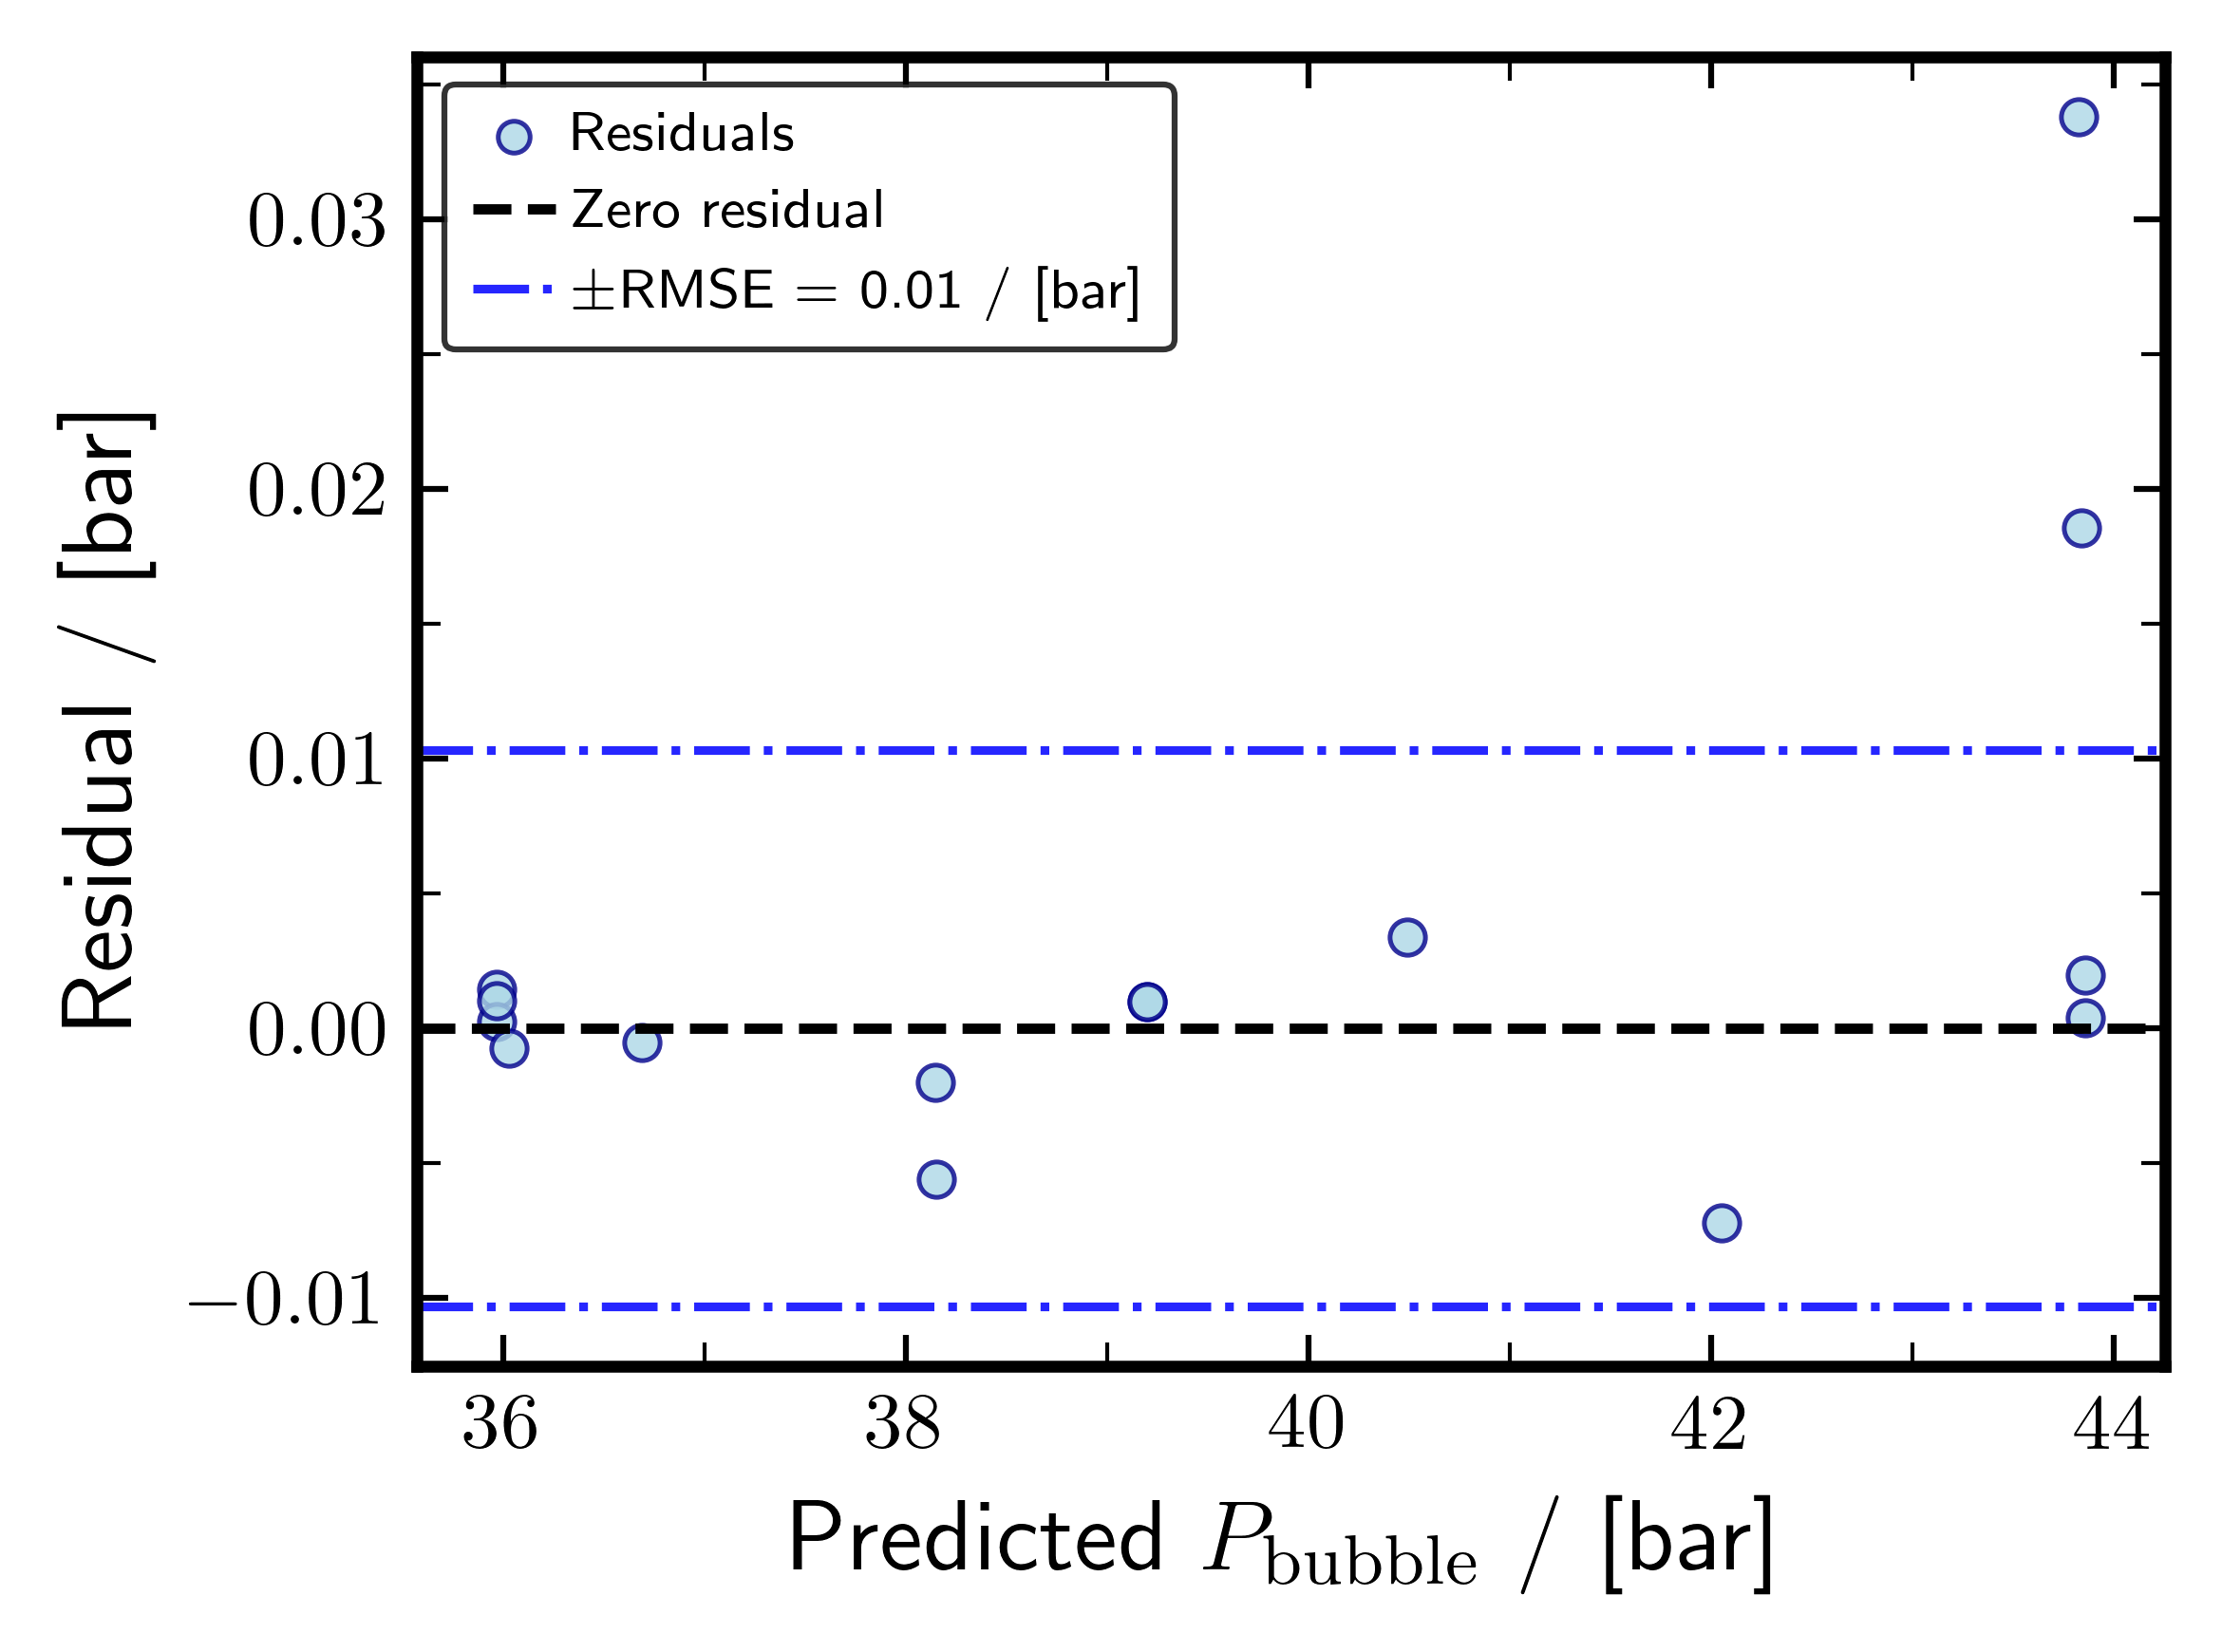

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Residual / [bar]'>)

In [13]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="TabPFN_P_bubble_residual_vs_predicted", folder=PLOT_FOLDER,
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

In [14]:
post.print_summary()

# Collect all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["model"]           = "TabPFN"
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

# Save metrics to JSON
os.makedirs(PLOT_FOLDER, exist_ok=True)
metrics_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_BUBBLE
Samples:        15
R² Score:       0.999989
RMSE:           0.010317
MAE:            0.005262
Mean Residual:  0.003123
Std Residual:   0.009833

Metrics saved to: TabPFN_OUTPUTS/TabPFN_P_bubble_metrics.json


In [15]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.54 minutes
